<a href="https://colab.research.google.com/github/nourelfeky/Telco-Customer-Churn-Ensemble-Learning/blob/main/Telco_Churn_Ensemble(Task2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

from sklearn.ensemble import (RandomForestClassifier,   # Bagging
                               AdaBoostClassifier,        # Boosting
                               GradientBoostingClassifier,# Boosting
                               VotingClassifier           # Voting
                               )

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore")


In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head(10)

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


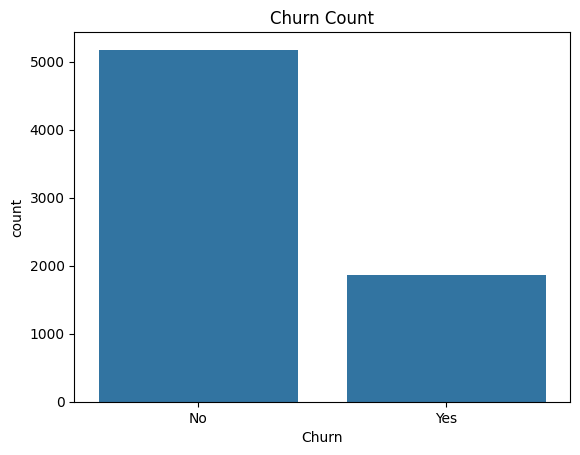

,proportion
Churn,
No,0.73463
Yes,0.26537


In [6]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Count')
plt.show()
df['Churn'].value_counts(normalize=True)

In [7]:
df = df.drop(columns=['customerID'])

In [9]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

Missing TotalCharges after conversion: 11


In [10]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print("Duplicate rows:", df.duplicated().sum())

df.dtypes


Duplicate rows: 22


,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [11]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns encoded:", cat_cols)

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Categorical columns encoded: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape after encoding: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [12]:
x = df_encoded.drop(columns='Churn')
y = df_encoded['Churn']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Train:", x_train_scaled.shape)
print("Test:", x_test_scaled.shape)

Train: (5634, 30)
Test: (1409, 30)


In [13]:
results = {}

def evaluate_model(model, x_tr, x_te, name):
    model.fit(x_tr, y_train)
    y_pred = model.predict(x_te)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name}: Accuracy = {accuracy:.3f}")
    return model


In [14]:
single_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
single_tree = evaluate_model(single_tree, x_train, x_test, "Single Decision Tree")

Single Decision Tree: Accuracy = 0.794


In [15]:
random_forest = RandomForestClassifier(n_estimators=200,
                                        max_depth=5,
                                        max_features='sqrt',
                                        n_jobs=-1,
                                        random_state=42)

random_forest = evaluate_model(random_forest, x_train, x_test, "Random Forest")


Random Forest: Accuracy = 0.793


In [16]:
ada_boost = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                n_estimators=200,
                                learning_rate=1,
                                random_state=42)

ada_boost = evaluate_model(ada_boost, x_train, x_test, "Ada Boost")

Ada Boost: Accuracy = 0.805


In [17]:
Gb = GradientBoostingClassifier(n_estimators=200,
                                 learning_rate=0.05,
                                 max_depth=3,
                                 random_state=42)

Gb = evaluate_model(Gb, x_train, x_test, "Gradient Boosting")


Gradient Boosting: Accuracy = 0.803


In [18]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg = evaluate_model(logreg, x_train, x_test, "Logistic Regression")

knn = KNeighborsClassifier(n_neighbors=7)
knn = evaluate_model(knn, x_train, x_test, "KNN")

tree_for_voting = DecisionTreeClassifier(max_depth=5, random_state=42)

voting_cls = VotingClassifier(estimators=[('logreg', logreg), ('knn', knn), ('tree', tree_for_voting)],
                               voting='soft')
voting_cls = evaluate_model(voting_cls, x_train_scaled, x_test_scaled, "Voting Classifier")


Logistic Regression: Accuracy = 0.803
KNN: Accuracy = 0.781
Voting Classifier: Accuracy = 0.796


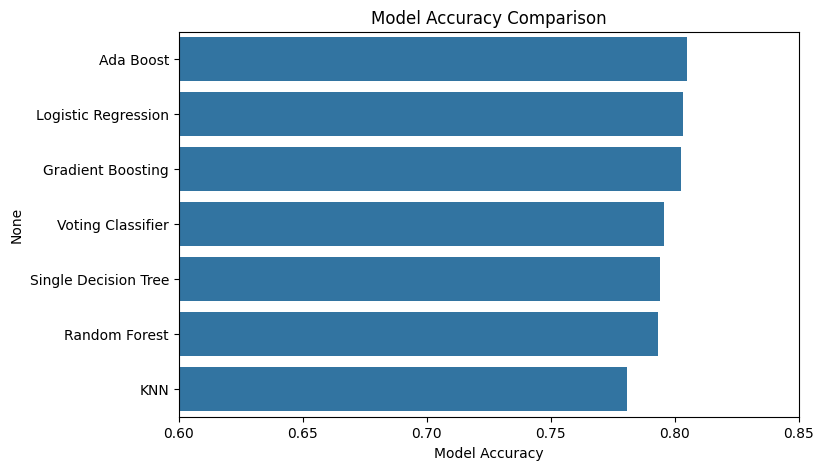

,0
Ada Boost,0.804826
Logistic Regression,0.803407
Gradient Boosting,0.802697
Voting Classifier,0.795600
Single Decision Tree,0.794180
Random Forest,0.793471
KNN,0.780696


In [19]:
result_df = pd.Series(results).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=result_df.values, y=result_df.index)
plt.xlabel("Model Accuracy")
plt.title("Model Accuracy Comparison")
plt.xlim(0.6, 0.85)
plt.show()

result_df

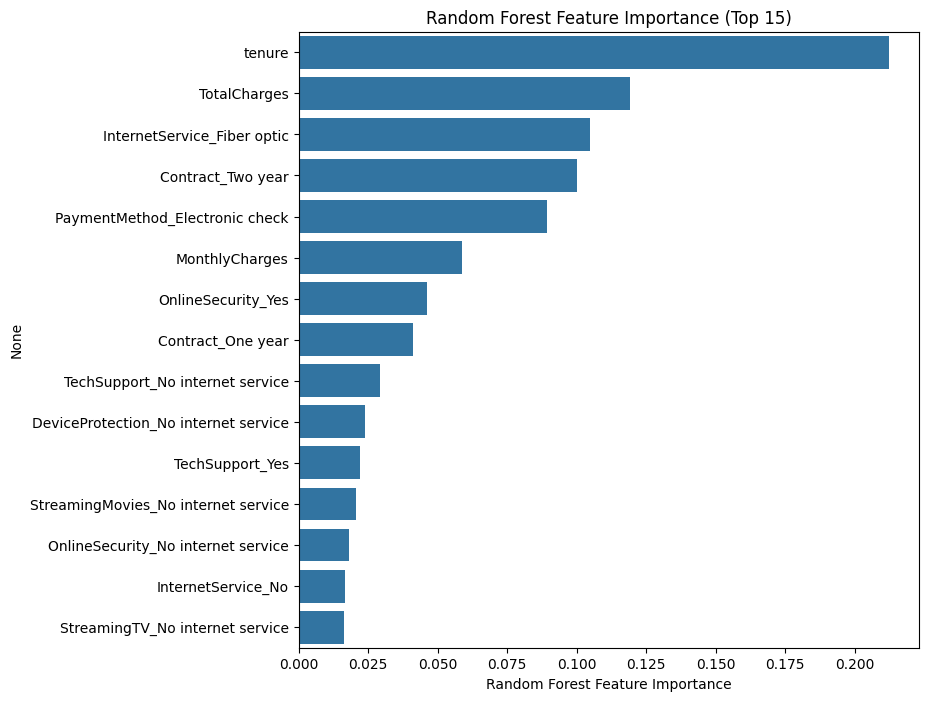

,0
tenure,0.212295
TotalCharges,0.119046
InternetService_Fiber optic,0.104614
Contract_Two year,0.100292
PaymentMethod_Electronic check,0.089448
MonthlyCharges,0.058736
OnlineSecurity_Yes,0.046293
Contract_One year,0.041277
TechSupport_No internet service,0.029438
DeviceProtection_No internet service,0.023750


In [20]:
rf_importances = pd.Series(random_forest.feature_importances_, index=x.columns)
rf_importances = rf_importances.sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=rf_importances.values[:15], y=rf_importances.index[:15])
plt.xlabel("Random Forest Feature Importance")
plt.title("Random Forest Feature Importance (Top 15)")
plt.show()
rf_importances.head(15)


Best Model: Ada Boost


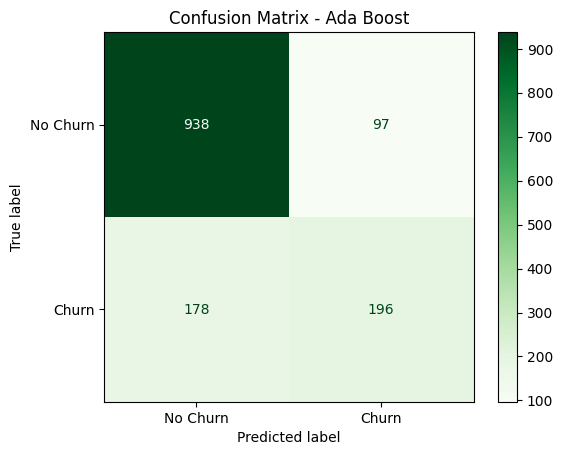

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [21]:
best_model_name = result_df.index[0]
print(f"Best Model: {best_model_name}")

x_te = x_test_scaled if best_model_name == "Voting Classifier" else x_test
best_model = {"Random Forest": random_forest,
              "Ada Boost": ada_boost,
              "Gradient Boosting": Gb,
              "Voting Classifier": voting_cls,
              "Single Decision Tree": single_tree,
              "Logistic Regression": logreg,
              "KNN": knn
              }[best_model_name]

y_pred_best = best_model.predict(x_te)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Greens')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))